--- Classification Report ---
              precision    recall  f1-score   support

        High       0.45      0.62      0.52       855
         Low       0.31      0.13      0.18       481
    Moderate       0.35      0.33      0.34       664

    accuracy                           0.41      2000
   macro avg       0.37      0.36      0.35      2000
weighted avg       0.38      0.41      0.38      2000



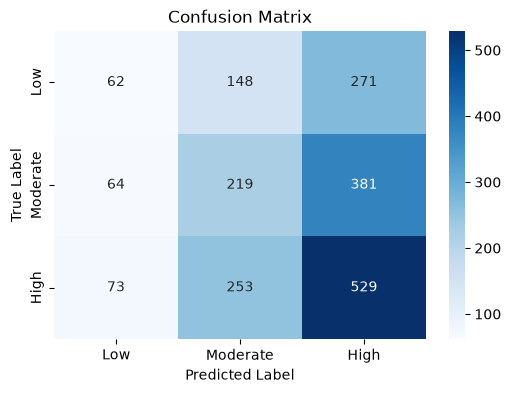

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load the data
df = pd.read_csv('../data/processed/engineered_smartphone_usage.csv')

# 2. Create Target Variable: Categorize usage intensity
def categorize_usage(hours):
    if hours < 4: return 'Low'
    elif hours < 8: return 'Moderate'
    else: return 'High'

df['Usage_Category'] = df['Daily_ScreenTime_Hours'].apply(categorize_usage)

# 3. Select Features
potential_features = ['SocialMedia_Min', 'Gaming_Min', 'Study_Min', 'Calls_Min', 'Battery_Drain_Percent']
features = [f for f in potential_features if f in df.columns]

X = df[features]
y = df['Usage_Category']

# 4. Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Random Forest Model
clf = RandomForestClassifier(random_state=42, n_estimators=100)
clf.fit(X_train, y_train)

# 6. Evaluate Model
y_pred = clf.predict(X_test)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 7. Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred, labels=['Low', 'Moderate', 'High'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low', 'Moderate', 'High'], 
            yticklabels=['Low', 'Moderate', 'High'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()